In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as psx
import plotly.graph_objects as go

In [2]:
data = pd.read_csv("Data/Validation.csv")
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<LI><B>RELATIONSHIPS BETWEEN DEPENDENT AND WITHIN INDEPENDENT FEATURES</B></LI>

In [3]:
data.corr(numeric_only=True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.144634,0.952294,0.052080,0.012757,-0.041955,0.878659,0.174648,-0.020545
person_income,0.144634,1.000000,0.134666,0.312441,-0.001361,-0.287149,0.128832,0.025462,-0.169034
person_emp_exp,0.952294,0.134666,1.000000,0.045792,0.016055,-0.038434,0.840146,0.182592,-0.019529
loan_amnt,0.052080,0.312441,0.045792,1.000000,0.146160,0.592972,0.043250,0.009126,0.107725
loan_int_rate,0.012757,-0.001361,0.016055,0.146160,1.000000,0.125322,0.017886,0.011339,0.332046
loan_percent_income,-0.041955,-0.287149,-0.038434,0.592972,0.125322,1.000000,-0.031436,-0.011064,0.384873
cb_person_cred_hist_length,0.878659,0.128832,0.840146,0.043250,0.017886,-0.031436,1.000000,0.154713,-0.014733
credit_score,0.174648,0.025462,0.182592,0.009126,0.011339,-0.011064,0.154713,1.000000,-0.007409
loan_status,-0.020545,-0.169034,-0.019529,0.107725,0.332046,0.384873,-0.014733,-0.007409,1.000000


In [6]:
Gender_age = data.groupby(["person_gender","person_education"]).size().reset_index(name="count")
Gender_age

,person_gender,person_education,count
0,female,Associate,5364
1,female,Bachelor,6018
2,female,Doctorate,275
3,female,High School,5340
4,female,Master,3160
5,male,Associate,6662
6,male,Bachelor,7378
7,male,Doctorate,346
8,male,High School,6630
9,male,Master,3820


In [7]:
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [10]:
Status_GM = data.groupby(["person_education","loan_status"]).size().reset_index(name="Count")
Status_GM

,person_education,loan_status,Count
0,Associate,0,9376
1,Associate,1,2650
2,Bachelor,0,10378
3,Bachelor,1,3018
4,Doctorate,0,479
5,Doctorate,1,142
6,High School,0,9299
7,High School,1,2671
8,Master,0,5461
9,Master,1,1519


In [13]:
Dependents_Status = data.groupby(["previous_loan_defaults_on_file","loan_status"]).size().reset_index(name="Counts")
Dependents_Status

,previous_loan_defaults_on_file,loan_status,Counts
0,No,0,12137
1,No,1,10000
2,Yes,0,22856


In [14]:
Employed_Status = data.groupby(["loan_intent","loan_status"]).size().reset_index(name="Counts")
Employed_Status

,loan_intent,loan_status,Counts
0,DEBTCONSOLIDATION,0,4982
1,DEBTCONSOLIDATION,1,2163
2,EDUCATION,0,7599
3,EDUCATION,1,1552
4,HOMEIMPROVEMENT,0,3525
5,HOMEIMPROVEMENT,1,1258
6,MEDICAL,0,6170
7,MEDICAL,1,2378
8,PERSONAL,0,6030
9,PERSONAL,1,1521


In [15]:
applicant_avg = round(sum(data["person_income"])/len(data["person_income"]),2)
below_avg = data[data["person_income"]<applicant_avg]
above_avg = data[data["person_income"]>applicant_avg]

In [16]:
b = below_avg.groupby(["person_income","loan_status"]).size().reset_index(name="Counts")
below_status = b.groupby(["loan_status"])["Counts"].sum().reset_index(name="Total")

In [17]:
#Loan_status on the basis of below avg applicant Income
below_status

,loan_status,Total
0,0,20488
1,1,8077


In [18]:
a = above_avg.groupby(["person_income","loan_status"]).size().reset_index(name="Counts")
above_status = a.groupby(["loan_status"])["Counts"].sum().reset_index(name="Total")

In [19]:
#Loan_status on the basis of above avg applicant Income
above_status

,loan_status,Total
0,0,14505
1,1,1923


In [21]:
Area_Status = data.groupby(["person_home_ownership","loan_status"]).size().reset_index(name="Counts")
Area_Status

,person_home_ownership,loan_status,Counts
0,MORTGAGE,0,16341
1,MORTGAGE,1,2144
2,OTHER,0,78
3,OTHER,1,39
4,OWN,0,2729
5,OWN,1,222
6,RENT,0,15845
7,RENT,1,7595


<h1><b>UNIVARIATE ANALYSIS</b></h1>

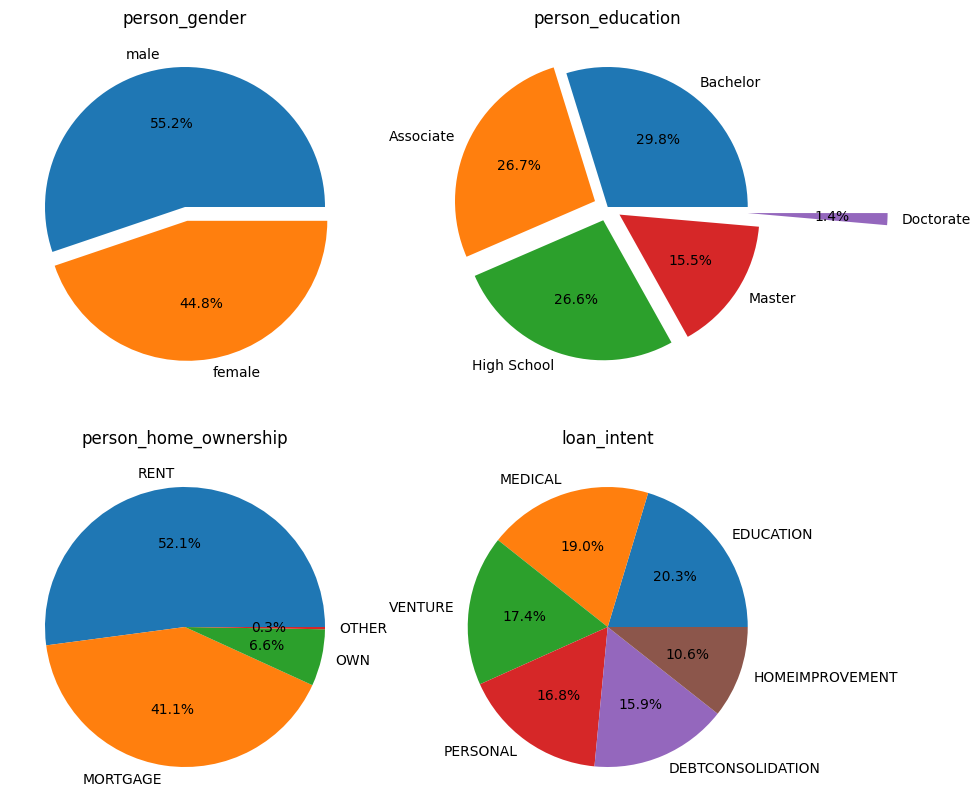

In [24]:
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))
data["person_gender"].value_counts().plot.pie(autopct="%1.1f%%",title="person_gender",ax=ax[0][0],explode=(0,0.1))
data["person_education"].value_counts().plot.pie(autopct="%1.1f%%",title="person_education",ax=ax[0][1],explode=(0,0.1,0.1,0.1,1))
data["person_home_ownership"].value_counts().plot.pie(autopct="%1.1f%%",title="person_home_ownership",ax=ax[1][0])
data["loan_intent"].value_counts().plot.pie(autopct="%1.1f%%",title="loan_intent",ax=ax[1][1])
plt.savefig("CategoricalUNIVARIATE.png",dpi=100)
plt.show()

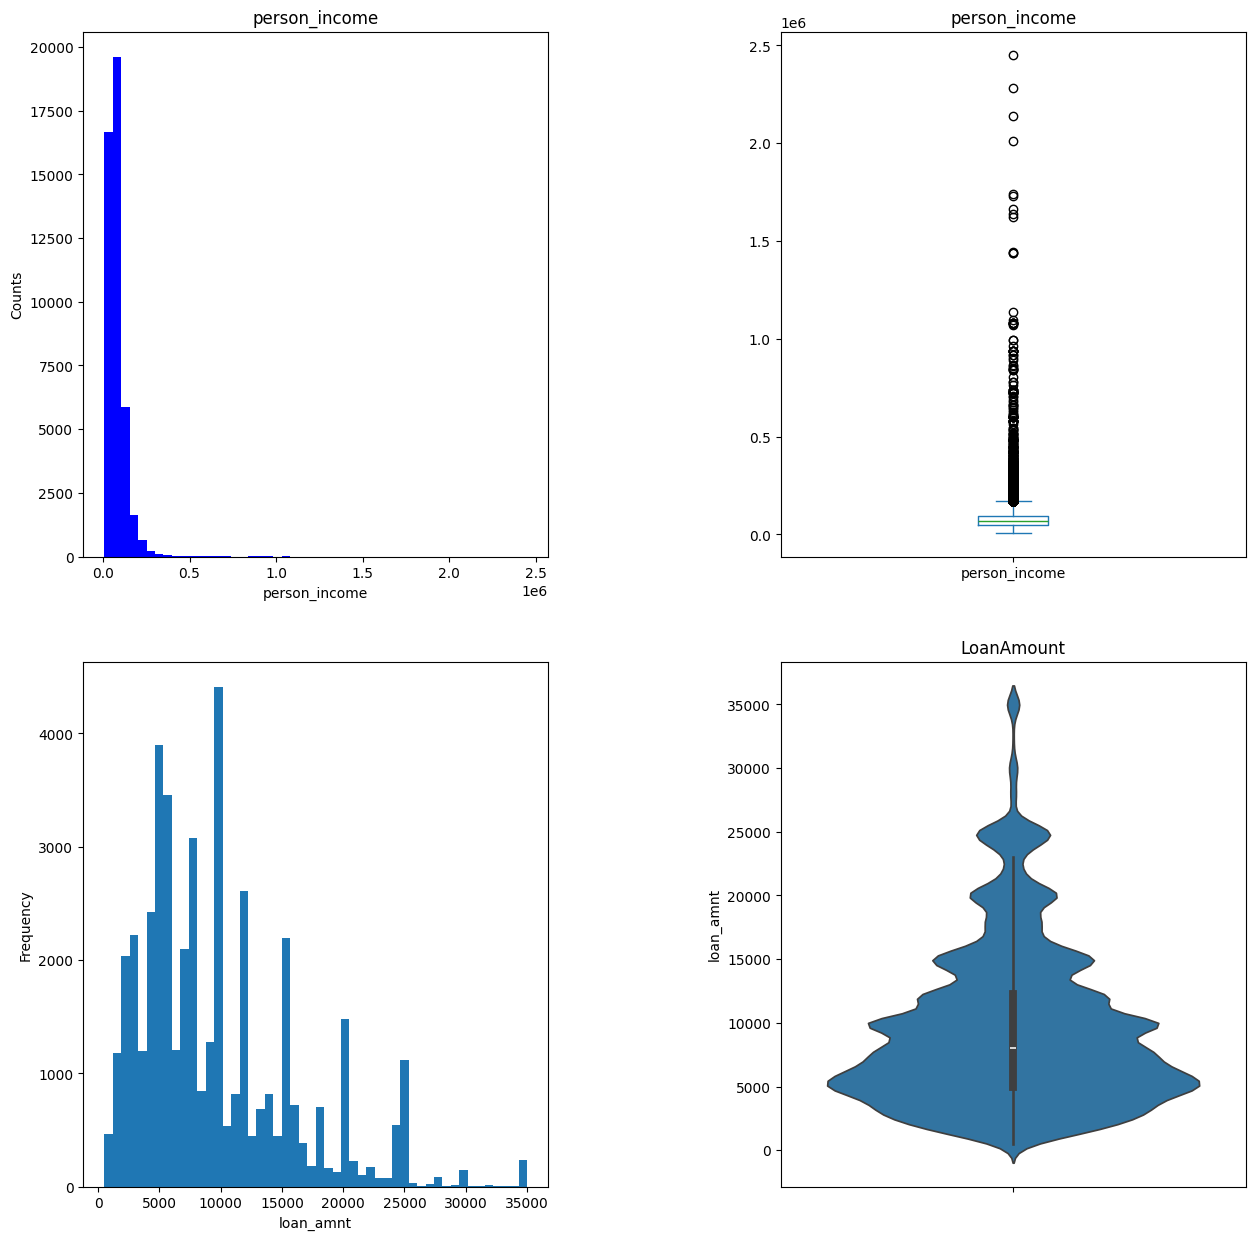

In [25]:
fig,ax = plt.subplots(2,2,figsize=(15,15))
plt.subplots_adjust(hspace=0.2, wspace=0.5)
data["person_income"].plot.box(ax=ax[0][1],title="person_income")
data["person_income"].plot.hist(xlabel="person_income",bins=(50),ylabel="Counts",ax=ax[0][0],color="blue",title="person_income")
data["loan_amnt"].plot.hist(xlabel="loan_amnt",bins=(50),ax=ax[1][0])
sns.violinplot(data["loan_amnt"],ax=ax[1][1])
ax[1,1].set_title("LoanAmount")
plt.savefig("NumericalUNIVARIATE.png",dpi=100)
#data["LoanAmount"].plot.violin(ax=ax[1][1],title="LoanAmount")
plt.show()

<h1><b>BIVARIATE ANALYSIS</b></h1>

In [22]:
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [21]:
pie = Employed_Status.groupby(["Self_Employed","Loan_Status"])["Counts"].sum()

KeyError: 'Loan_Status'

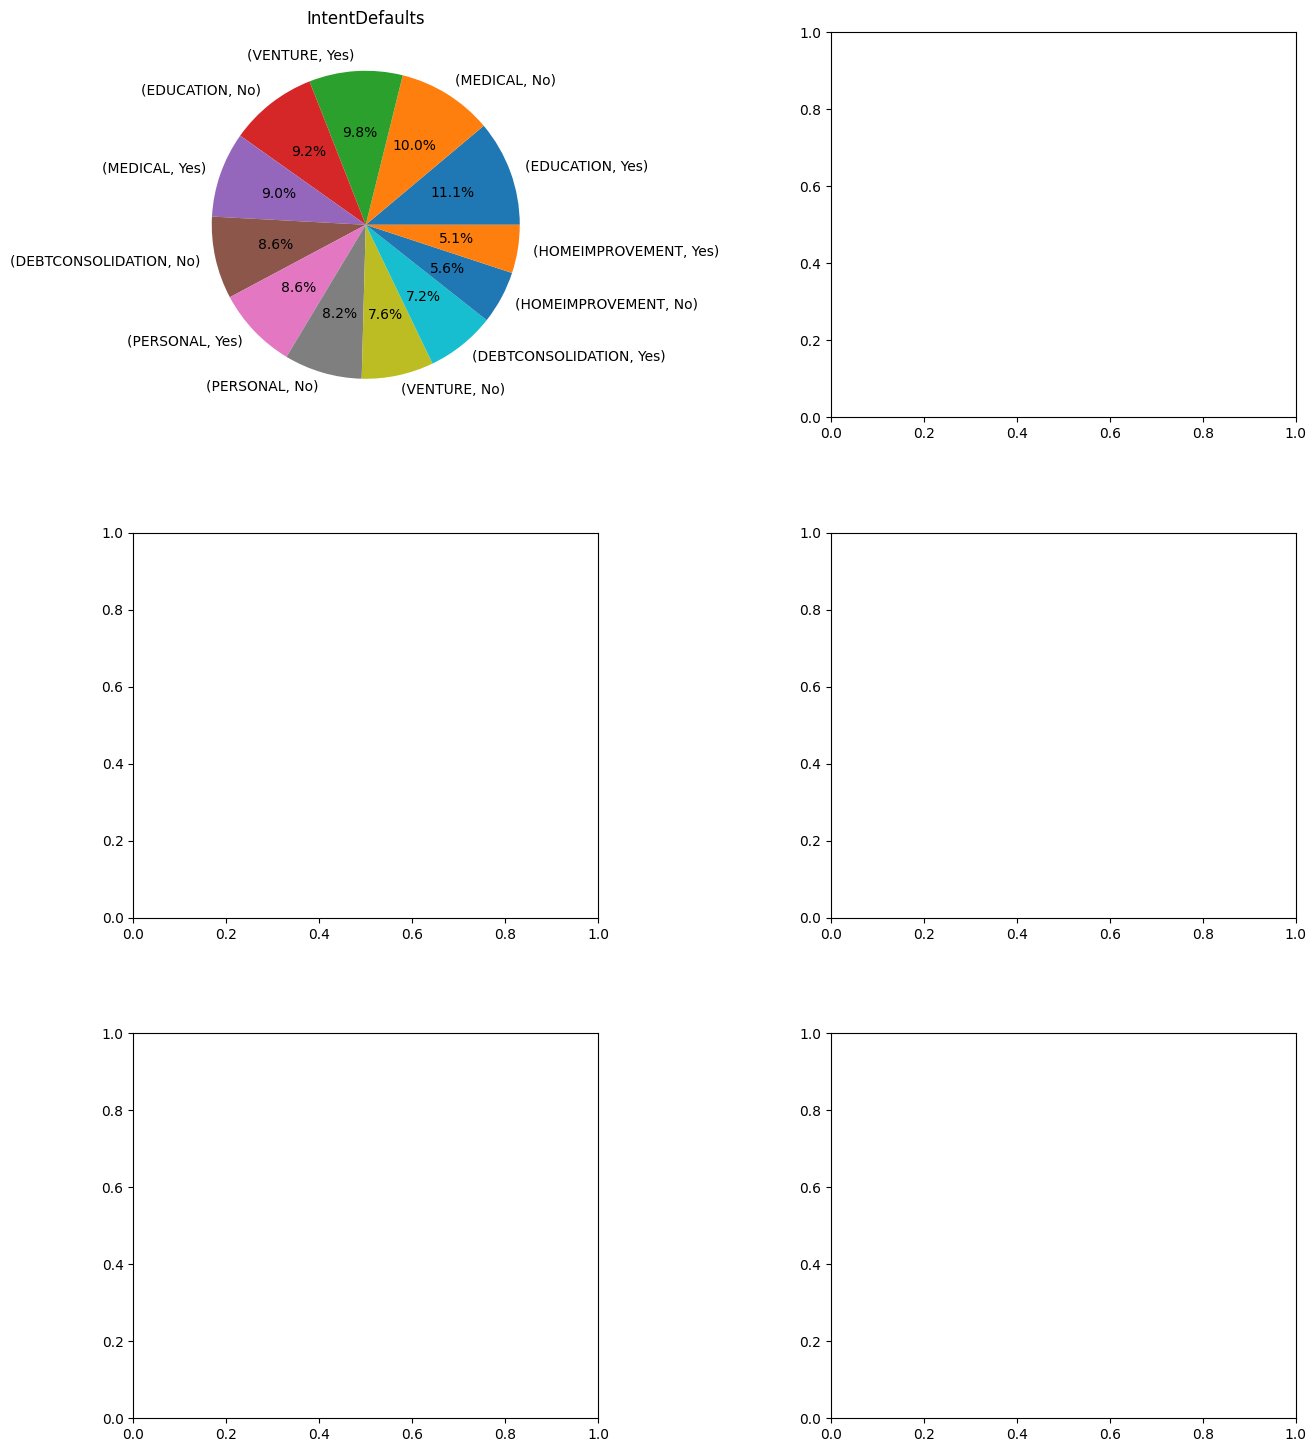

In [27]:
fig,ax = plt.subplots(3,2,figsize=(15,18))
plt.subplots_adjust(hspace=0.3,wspace=0.5)
data.iloc[:,[7,12]].value_counts().plot.pie(autopct="%1.1f%%",title="IntentDefaults",
                                          ax=ax[0,0])

sns.barplot(x=Status_GM["Loan_Status"],y=Status_GM["Count"],hue=Status_GM["person_education"],ax=ax[0,1])
ax[0,1].set_title("LoanStatus")
sns.barplot(x=Dependents_Status["Loan_Status"],y=Dependents_Status["Counts"],hue=Dependents_Status["previous_loan_defaults_on_file"],ax=ax[1,0])
ax[1,0].set_title("Defaults_Status")
# pie.plot.pie(subplots=True,autopct="%1.1f%%",ax=ax[1,1])
# ax[1,1].set_title("Defaults_Status")
sns.barplot(x=Area_Status["Loan_Status"],y=Area_Status["Counts"],hue=Area_Status["person_home_ownership"],ax=ax[2,0])
ax[2,0].set_title("person_home_ownership")
ax[2,1].axis("off")
plt.savefig("CategoricalBIVARIATE.png",dpi=100)
plt.show()

C:\Users\lipun\AppData\Local\Temp\ipykernel_22036\2974001194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=below_status["Loan_Status"],y=below_status["Total"],ax=ax[0,0],palette=["green","lightgreen"])
C:\Users\lipun\AppData\Local\Temp\ipykernel_22036\2974001194.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=above_status["Loan_Status"],y=above_status["Total"],ax=ax[0,1],palette=["lightblue","blue"])


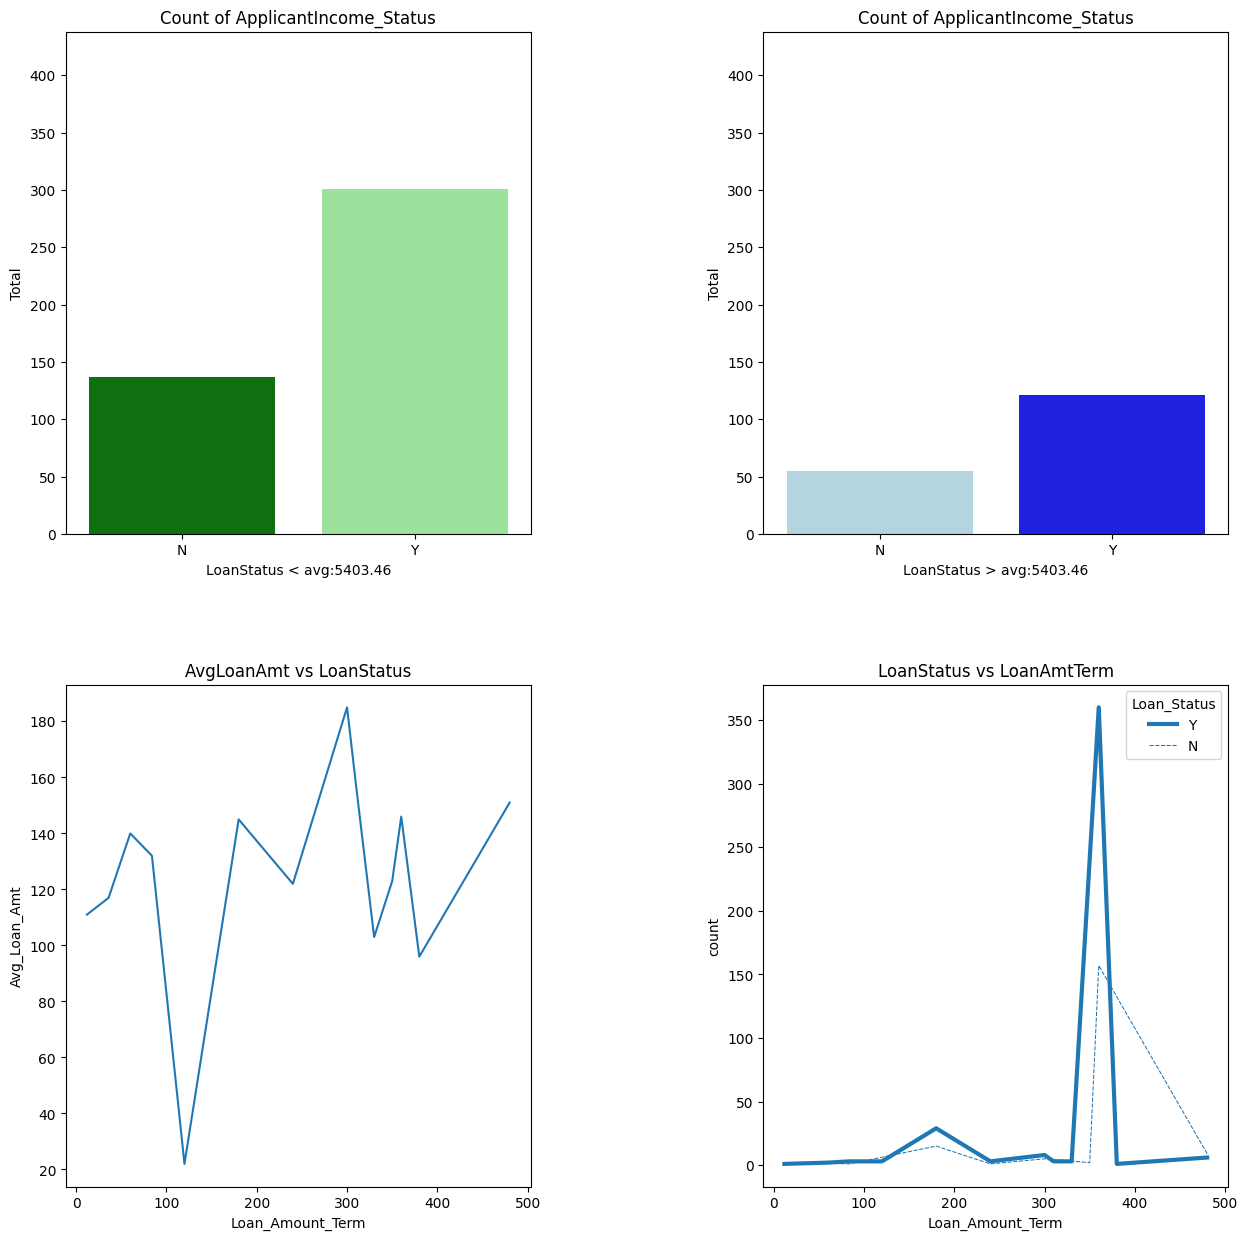

In [131]:
fig,ax = plt.subplots(2,2,figsize=(15,15))
fig.subplots_adjust(hspace=0.3,wspace=0.5)
sns.barplot(x=below_status["Loan_Status"],y=below_status["Total"],ax=ax[0,0],palette=["green","lightgreen"])
ax[0,0].set_xlabel("LoanStatus < avg:5403.46")
ax[0,0].set_title("Count of ApplicantIncome_Status")
ax[0,0].set_ylim(0,438)
sns.barplot(x=above_status["Loan_Status"],y=above_status["Total"],ax=ax[0,1],palette=["lightblue","blue"])
ax[0,1].set_xlabel("LoanStatus > avg:5403.46")
ax[0,1].set_title("Count of ApplicantIncome_Status")
ax[0,1].set_ylim(0,438)
sns.lineplot(x=merge["Loan_Amount_Term"],y=merge["Avg_Loan_Amt"],ax=ax[1,0])
ax[1,0].set_title("AvgLoanAmt vs LoanStatus")
sns.lineplot(x=loan_status_count_AmtTerm["Loan_Amount_Term"],y=loan_status_count_AmtTerm["count"],style=loan_status_count_AmtTerm["Loan_Status"],size=loan_status_count_AmtTerm["Loan_Status"],ax=ax[1,1])
ax[1,1].set_title("LoanStatus vs LoanAmtTerm")
plt.savefig("ContinuosBIVARIATE.png",dpi=100)
plt.show()